# Key ML & DL Imports

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Masking
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Drive and Load Data

In [ ]:
drive.mount('/content/drive')
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

CLASSES = ['Afternoon', 'Apple', 'April', 'August', 'Banana', 'Day', 'December', 'Evening',
           'Febraury', 'Friday', 'Grapes', 'January', 'July', 'June', 'March', 'May', 'Monday',
           'Morning', 'Night', 'November', 'October', 'Orange', 'Rainy', 'Saturday', 'September',
           'Summer', 'Sunday', 'Thursday', 'Tuesday', 'Valencia_Orange', 'Watermelon', 'Wednesday', 'Winter']
# Load data
X = np.load('/content/drive/MyDrive/X_195_75.npy')
y = np.load('/content/drive/MyDrive/y_195_75.npy')

Mounted at /content/drive


 # Data Transformation and Normalization

In [ ]:
# Normalize features
scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped).reshape(X.shape)

# Split data (70% train, 20% test, 10% validation)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, stratify=y_train, random_state=42)
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}")

# Convert labels to one-hot encoding
num_classes = 33
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)
print(f"Shape of y_train_cat: {y_train_cat.shape}")
print(f"Shape of y_val_cat: {y_val_cat.shape}")
print(f"Shape of y_test_cat: {y_test_cat.shape}")

X_train shape: (1623, 75, 195), X_val shape: (232, 75, 195), X_test shape: (464, 75, 195)
Shape of y_train_cat: (1623, 33)
Shape of y_val_cat: (232, 33)
Shape of y_test_cat: (464, 33)


In [ ]:
# Compute class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Define custom LSTM model

In [ ]:
def create_improved_unidirectional_lstm_model(input_shape, num_classes):
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=input_shape))  # Added for padded sequences
    model.add(LSTM(256, return_sequences=True, kernel_regularizer=l2(0.01), recurrent_dropout=0.2))
    model.add(Dropout(0.6))
    model.add(BatchNormalization())
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.01), recurrent_dropout=0.2))
    model.add(Dropout(0.6))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.6))
    model.add(BatchNormalization())
    model.add(Dense(num_classes, activation='softmax'))
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create and summarize the model
model = create_improved_unidirectional_lstm_model(input_shape=(75, 195), num_classes=num_classes)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 75, 195)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 75, 256)        │       462,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,785 (2.60 MB)

 Trainable params: 681,761 (2.60 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # Adjusted patience
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# Train the model
history = model.fit(X_train, y_train_cat,
                    validation_data=(X_val, y_val_cat),
                    epochs=200,
                    batch_size=32,
                    class_weight=class_weight_dict,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=1)

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 640ms/step - accuracy: 0.0312 - loss: 12.1604 - val_accuracy: 0.0388 - val_loss: 11.2603 - learning_rate: 1.0000e-04
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 570ms/step - accuracy: 0.0384 - loss: 11.8725 - val_accuracy: 0.0690 - val_loss: 11.0348 - learning_rate: 1.0000e-04
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 568ms/step - accuracy: 0.0485 - loss: 11.6059 - val_accuracy: 0.0948 - val_loss: 10.7842 - learning_rate: 1.0000e-04
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 557ms/step - accuracy: 0.0698 - loss: 11.3586 - val_accuracy: 0.1078 - val_loss: 10.5405 - learning_rate: 1.0000e-04
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 554ms/step - accuracy: 0.0670 - loss: 11.1783 - val_accuracy: 0.1121 - val_loss: 10.3293 - learning_rate: 1.0000e-04
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 42s 567ms/step - accuracy: 0.0708 - loss: 10.9279 - val_accuracy: 0.1422 - val_loss: 10.1106 - learning_rate: 1.0000e-04
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 4

# Save the model

In [ ]:
model.save('/content/drive/MyDrive/LSTM_KSL.keras')
print("Model saved successfully in keras format.")

Model saved successfully in keras format.


# Visualization and plots

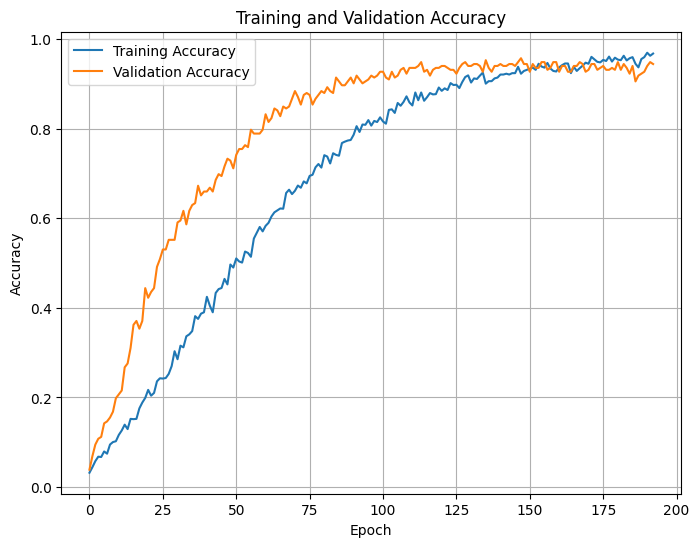

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Generate predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Generate and print the classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=CLASSES, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES))

# Print macro, micro, and weighted average metrics
print("\nAverages:")
print("  Macro Average:")
print(f"    Precision: {report['macro avg']['precision']:.4f}")
print(f"    Recall: {report['macro avg']['recall']:.4f}")
print(f"    F1-score: {report['macro avg']['f1-score']:.4f}")
print(f"    Support: {report['macro avg']['support']}")

print("\n  Micro Average:")
print(f"    Precision: {report['accuracy']:.4f}") # Micro average precision is accuracy
print(f"    Recall: {report['accuracy']:.4f}")    # Micro average recall is accuracy
print(f"    F1-score: {report['accuracy']:.4f}")    # Micro average f1-score is accuracy
print(f"    Support: {report['accuracy'] * report['macro avg']['support']:.0f}") # Total number of samples

print("\n  Weighted Average:")
print(f"    Precision: {report['weighted avg']['precision']:.4f}")
print(f"    Recall: {report['weighted avg']['recall']:.4f}")
print(f"    F1-score: {report['weighted avg']['f1-score']:.4f}")
print(f"    Support: {report['weighted avg']['support']}")

Test Accuracy: 0.9203
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step

Classification Report:
                 precision    recall  f1-score   support

      Afternoon       0.80      0.92      0.86        13
          Apple       1.00      1.00      1.00        13
          April       0.76      0.93      0.84        14
         August       0.93      1.00      0.97        14
         Banana       0.80      0.92      0.86        13
            Day       1.00      1.00      1.00        14
       December       1.00      1.00      1.00        14
        Evening       1.00      0.69      0.82        13
       Febraury       0.78      1.00      0.88        14
         Friday       1.00      1.00      1.00        14
         Grapes       1.00      1.00      1.00        15
        January       0.93      0.93      0.93        14
           July       0.78      1.00      0.88        14
           June       1.00      0.57      0.73        14
          March       0.93      0.93      0.93        14
 

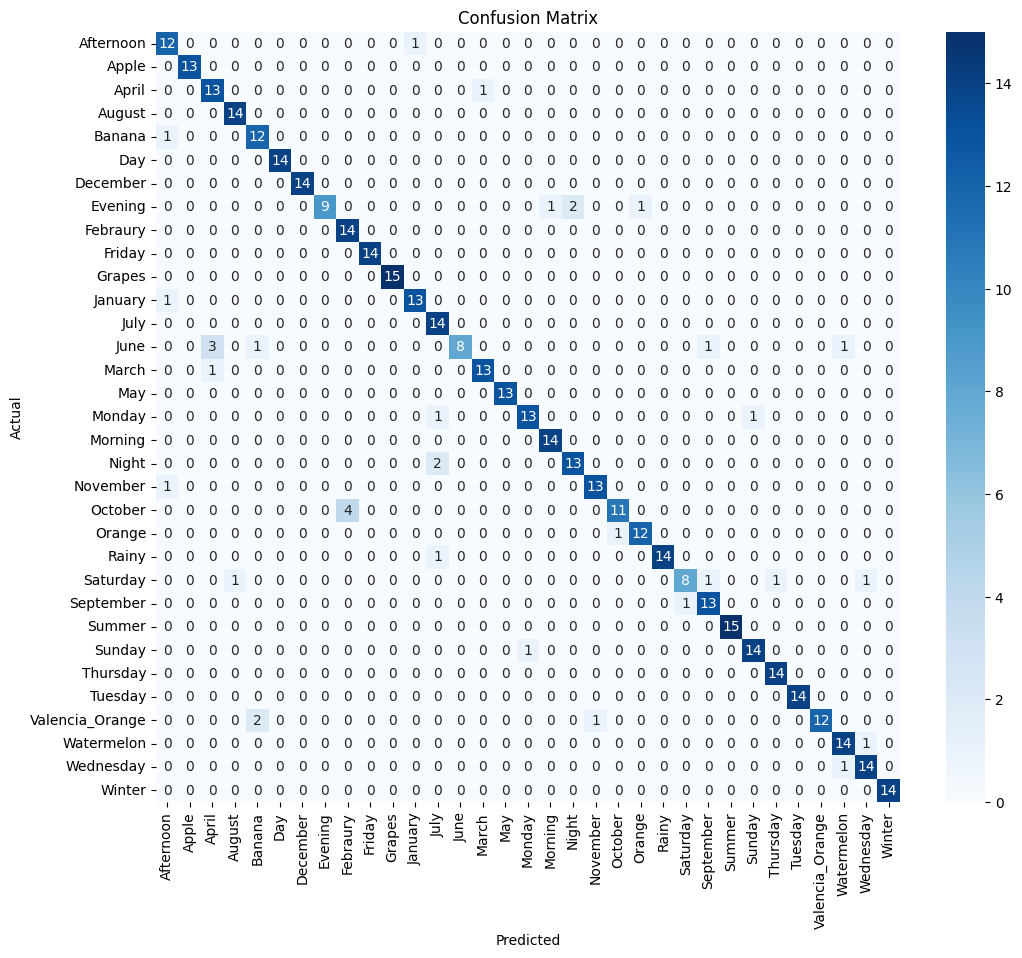

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()